# Spam Email Classification Benchmark
### MDI3003 - Advanced Predictive Analytics | Lab 03 (Adapted Scope)

Registration Number: 23MID0296
Student: Sarah Blessy

## Dataset Reference

**Name:** Enron-Spam Dataset (cleaned single-CSV release)

**Original corpus:** Metsis, V., Androutsopoulos, I., and Paliouras, G. (2006). Spam Filtering with Naive Bayes - Which Naive Bayes? Proceedings of CEAS 2006. Original data: http://www2.aueb.gr/users/ion/data/enron-spam/

**CSV release used in this notebook:** MWiechmann/enron_spam_data, https://github.com/MWiechmann/enron_spam_data

**Rows:** 33,716 emails (17,171 spam, 16,545 ham)

**Columns:** `Message ID`, `Subject`, `Message`, `Spam/Ham`, `Date`

**License / permitted use:** Original corpus released for research use; the CSV release is shared publicly on GitHub for research and educational use.

This dataset was chosen over the previously used UCI Spambase dataset because it contains **raw subject and body text**, which is required to build the leakage-safe TF-IDF pipelines described in the Lab 03 objectives below. Spambase only contains 57 pre-computed numeric features and cannot support text-based classification or TF-IDF work.

## Lab Objectives (MDI3003 Lab 03, Section 2)

- Formulate email assistance as linked classification and conditional text-generation tasks.
- Load, document, audit, and compare multiple email datasets with different domains and label spaces.
- Construct leakage-safe TF-IDF pipelines for sparse text classification.
- Implement and compare a dummy baseline, MultinomialNB, ComplementNB, Logistic Regression, and LinearSVC; then implement a trainable word-embedding BiLSTM as the deep-learning classifier in the research extension.
- Select models using training-only repeated cross-validation, macro F1, uncertainty, computational cost, and operational error severity rather than test-set trial and error.
- Evaluate within-dataset generalization and, for compatible spam corpora, cross-dataset transfer.
- Classify a new email and implement selective prediction: generate, suppress, or abstain/manual-review using a threshold selected on validation data.
- Call an approved LLM API to generate a professional email subject and body conditioned on the predicted class.
- Prevent API-key leakage, personal-data disclosure, prompt injection, invented commitments, and automatic sending.
- Compare a deterministic template baseline with LLM drafts using stratified cases, blinded pairwise preference, two independent raters, factual faithfulness, safety, edit effort, and agreement.
- Produce reproducible classification artifacts and a transparent industry-style system report.

## Scope Note

This notebook covers the objectives that a single-dataset, classical-ML benchmark can satisfy: leakage-safe TF-IDF pipelines, a dummy baseline plus MultinomialNB, ComplementNB, Logistic Regression, and LinearSVC, training-only cross-validation with macro F1, and a locked-test evaluation with a full metric and visualization suite.

The following objectives remain out of scope for this notebook and require additional datasets or components not yet available:

- Multi-dataset comparison and cross-dataset spam transfer (needs a second binary spam corpus such as SpamAssassin, plus the business-intent dataset D1).
- Selective prediction / abstention routing tied to business-intent labels (needs D1).
- The LLM API drafting stage, prompt-injection testing, and human draft evaluation (needs raw text plus an approved LLM API key, and is tied to D1's intent labels).
- The trainable word-embedding BiLSTM research extension (a separate, heavier notebook given its training time and TensorFlow dependency).

These remain to be built once the business-intent dataset is sourced from the course instructor.

## Contents

1. Imports and configuration
2. Dataset loading
3. Dataset audit
4. Visualization: class balance, text length distributions, engineered-feature correlation heatmap
5. Locked train/test split
6. TF-IDF pipeline registry and training-only cross-validation (accuracy and macro F1)
7. Locked-test evaluation
8. Regression-style error metrics (MAE / MSE / RMSE)
9. Classification metrics (accuracy, precision, recall, F1, ROC-AUC) for all models
10. Visual diagnostics: confusion matrices, ROC curves, top predictive terms
11. Result tables and saved artifacts
12. Conclusion

## 1. Imports and configuration

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.facecolor"] = "white"

## 2. Dataset loading

The raw CSV has columns `Message ID`, `Subject`, `Message`, `Spam/Ham`, `Date`. It is normalized to the schema used across this notebook: `email_id`, `subject`, `body`, `label`, `text`.

In [2]:
raw = pd.read_csv(DATA_DIR / "enron_spam_data.csv")

df = pd.DataFrame({
    "email_id": raw["Message ID"],
    "subject": raw["Subject"].fillna(""),
    "body": raw["Message"].fillna(""),
    "label": raw["Spam/Ham"].str.strip().str.lower(),
    "date": raw["Date"],
})
df["text"] = "subject: " + df["subject"].str.strip() + "\nbody: " + df["body"].str.strip()
df["is_spam"] = (df["label"] == "spam").astype(int)

print("Shape:", df.shape)
df.head()

Shape: (33716, 7)


,email_id,subject,body,label,date,text,is_spam
0,0,christmas tree farm pictures,,ham,1999-12-10,subject: christmas tree farm pictures\nbody:,0
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,"subject: vastar resources , inc .\nbody: gary ...",0
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,subject: calpine daily gas nomination\nbody: -...,0
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,subject: re : issue\nbody: fyi - see note belo...,0
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,subject: meter 7268 nov allocation\nbody: fyi ...,0


## 3. Dataset audit

Row/column counts, missing values, duplicate rows, and class balance, checked before any modeling (manual Section 11.3).

In [3]:
audit = {
    "rows": len(df),
    "missing_subject": int((raw["Subject"].isna()).sum()),
    "missing_body": int((raw["Message"].isna()).sum()),
    "duplicate_text_rows": int(df["text"].duplicated().sum()),
    "spam_count": int((df["is_spam"] == 1).sum()),
    "ham_count": int((df["is_spam"] == 0).sum()),
    "spam_pct": round(100 * df["is_spam"].mean(), 2),
}
audit_df = pd.DataFrame([audit])
audit_df

,rows,missing_subject,missing_body,duplicate_text_rows,spam_count,ham_count,spam_pct
0,33716,289,371,3253,17171,16545,50.93


In [4]:
n_dupes = df["text"].duplicated().sum()
print(f"Duplicate text rows found: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates(subset="text").reset_index(drop=True)
    print(f"Dropped exact duplicate text rows. New shape: {df.shape}")

Duplicate text rows found: 3253
Dropped exact duplicate text rows. New shape: (30463, 7)


In [5]:
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df.groupby("label")[["text_length", "word_count"]].describe().round(2)

text_length                                                          \
            count    mean      std   min    25%    50%      75%       max   
label                                                                       
ham       15910.0  1640.4  5394.74  19.0  355.0  805.0  1689.75  228383.0   
spam      14553.0  1331.0  1936.31  16.0  363.0  665.0  1404.00   28767.0   

      word_count                                                     
           count    mean      std  min   25%    50%    75%      max  
label                                                                
ham      15910.0  348.36  1075.10  3.0  75.0  176.0  370.0  45452.0  
spam     14553.0  263.78   382.53  2.0  73.0  139.0  278.0   8403.0

## 4. Visualization: class balance, text length, correlation heatmap

### 4.1 Class distribution

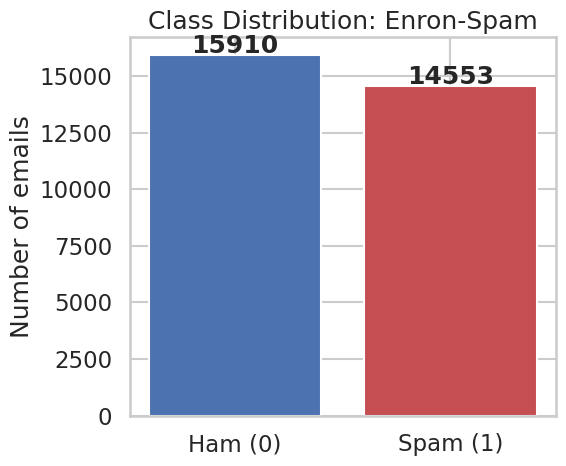

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = df["is_spam"].value_counts().sort_index()
labels = ["Ham (0)", "Spam (1)"]
colors = ["#4C72B0", "#C44E52"]
ax.bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha="center", fontweight="bold")
ax.set_title("Class Distribution: Enron-Spam")
ax.set_ylabel("Number of emails")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "class_distribution.png", dpi=150)
plt.show()

### 4.2 Text length distribution by class

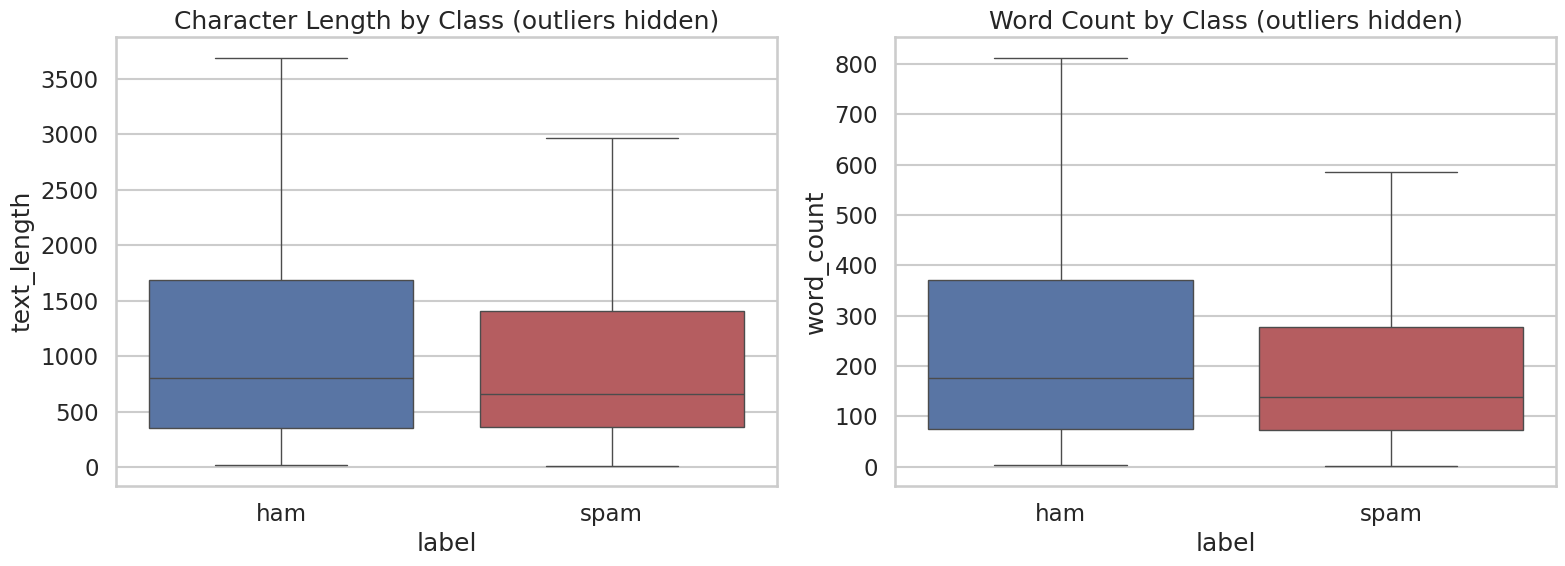

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x="label", y="text_length", ax=axes[0], palette=colors, showfliers=False)
axes[0].set_title("Character Length by Class (outliers hidden)")
sns.boxplot(data=df, x="label", y="word_count", ax=axes[1], palette=colors, showfliers=False)
axes[1].set_title("Word Count by Class (outliers hidden)")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "text_length_distributions.png", dpi=150)
plt.show()

### 4.3 Engineered-feature correlation heatmap

Raw TF-IDF text cannot be correlated directly (tens of thousands of sparse dimensions), so a small set of interpretable numeric features is engineered from the text to produce a meaningful correlation matrix and heatmap.

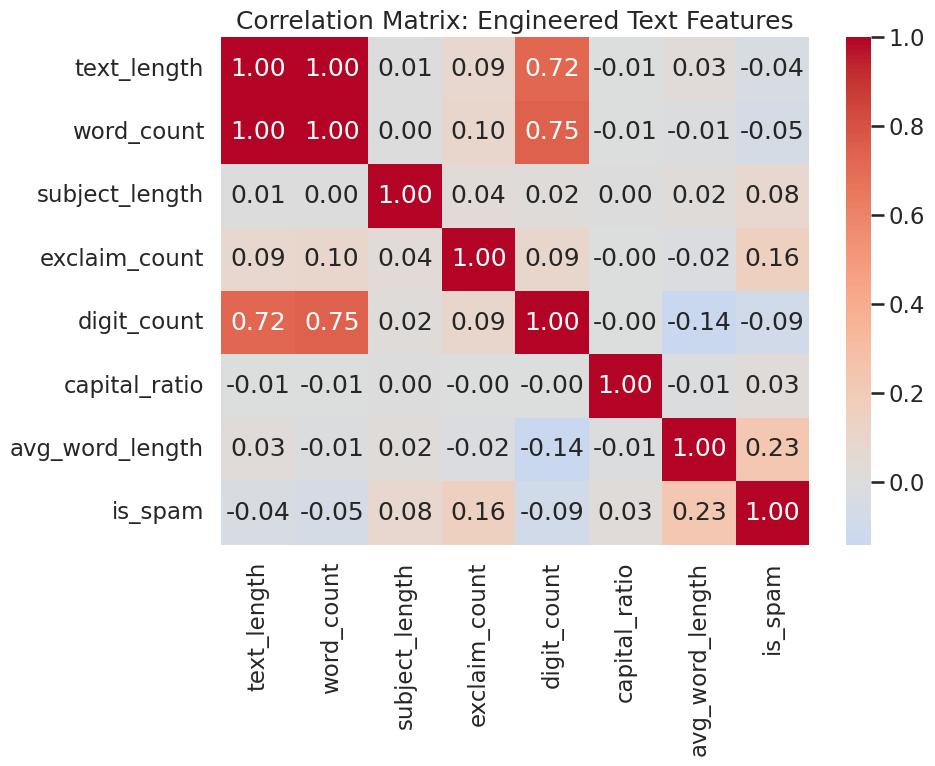

In [8]:
df["subject_length"] = df["subject"].str.len()
df["exclaim_count"] = df["text"].str.count("!")
df["digit_count"] = df["text"].str.count(r"\d")
df["capital_ratio"] = df["text"].apply(
    lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)
)
df["avg_word_length"] = df["text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)

engineered_cols = [
    "text_length", "word_count", "subject_length", "exclaim_count",
    "digit_count", "capital_ratio", "avg_word_length", "is_spam"
]
engineered_corr = df[engineered_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix: Engineered Text Features")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "correlation_heatmap_engineered.png", dpi=150)
plt.show()

## 5. Locked train/test split

Stratified 80/20 split, locked before any model comparison (manual Section 11.4).

In [9]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape[0], " Test:", X_test.shape[0])
print("Train spam rate: {:.2%}  Test spam rate: {:.2%}".format(
    (y_train == "spam").mean(), (y_test == "spam").mean()
))

Train: 24370  Test: 6093
Train spam rate: 47.77%  Test spam rate: 47.78%


## 6. TF-IDF pipeline registry and training-only cross-validation

Five classifiers per the Lab 03 objectives: a dummy baseline, MultinomialNB, ComplementNB, Logistic Regression, and LinearSVC. Each is wrapped in a `Pipeline` with `TfidfVectorizer`, so the vocabulary and IDF weights are fit only inside each training fold, preventing leakage. 5-fold stratified CV is run on the training set only; the test set stays locked until Section 7.

To keep runtime reasonable, cross-validation fits the vectorizer once per fold and reuses the resulting matrix across all five classifiers in that fold, instead of re-vectorizing text separately for every model.

In [10]:
def make_vectorizer():
    return TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        sublinear_tf=True,
        max_features=40000,
    )

def make_pipeline(classifier):
    return Pipeline([("tfidf", make_vectorizer()), ("classifier", classifier)])

def make_classifiers():
    return {
        "dummy_majority": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
        "multinomial_nb": MultinomialNB(alpha=1.0),
        "complement_nb": ComplementNB(alpha=1.0),
        "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        "linear_svc": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    }

MODEL_NAMES = list(make_classifiers().keys())
MODELS = {name: make_pipeline(clf) for name, clf in make_classifiers().items()}

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_train_arr = X_train.reset_index(drop=True)
y_train_arr = y_train.reset_index(drop=True)

fold_scores = {name: {"accuracy": [], "macro_f1": []} for name in MODEL_NAMES}

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr), start=1):
    fold_vectorizer = make_vectorizer()
    X_fold_train = fold_vectorizer.fit_transform(X_train_arr.iloc[train_idx])
    X_fold_val = fold_vectorizer.transform(X_train_arr.iloc[val_idx])
    y_fold_train = y_train_arr.iloc[train_idx]
    y_fold_val = y_train_arr.iloc[val_idx]

    for name, clf in make_classifiers().items():
        clf.fit(X_fold_train, y_fold_train)
        pred = clf.predict(X_fold_val)
        fold_scores[name]["accuracy"].append(accuracy_score(y_fold_val, pred))
        fold_scores[name]["macro_f1"].append(f1_score(y_fold_val, pred, average="macro"))
    print(f"Fold {fold_idx}/5 done.")

cv_rows = []
for name in MODEL_NAMES:
    acc = np.array(fold_scores[name]["accuracy"])
    f1m = np.array(fold_scores[name]["macro_f1"])
    cv_rows.append({
        "model": name,
        "cv_accuracy": acc.mean(),
        "cv_accuracy_sd": acc.std(),
        "cv_macro_f1": f1m.mean(),
        "cv_macro_f1_sd": f1m.std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
cv_results.to_csv(OUT_DIR / "cv_results.csv", index=False)
cv_results.round(4)

Fold 1/5 done.


Fold 2/5 done.


Fold 3/5 done.


Fold 4/5 done.


Fold 5/5 done.


,model,cv_accuracy,cv_accuracy_sd,cv_macro_f1,cv_macro_f1_sd
0,linear_svc,0.9918,0.0014,0.9918,0.0014
1,logistic_regression,0.9876,0.0012,0.9876,0.0012
2,complement_nb,0.9862,0.0014,0.9862,0.0014
3,multinomial_nb,0.9862,0.0011,0.9862,0.0012
4,dummy_majority,0.5223,0.0001,0.3431,0.0000


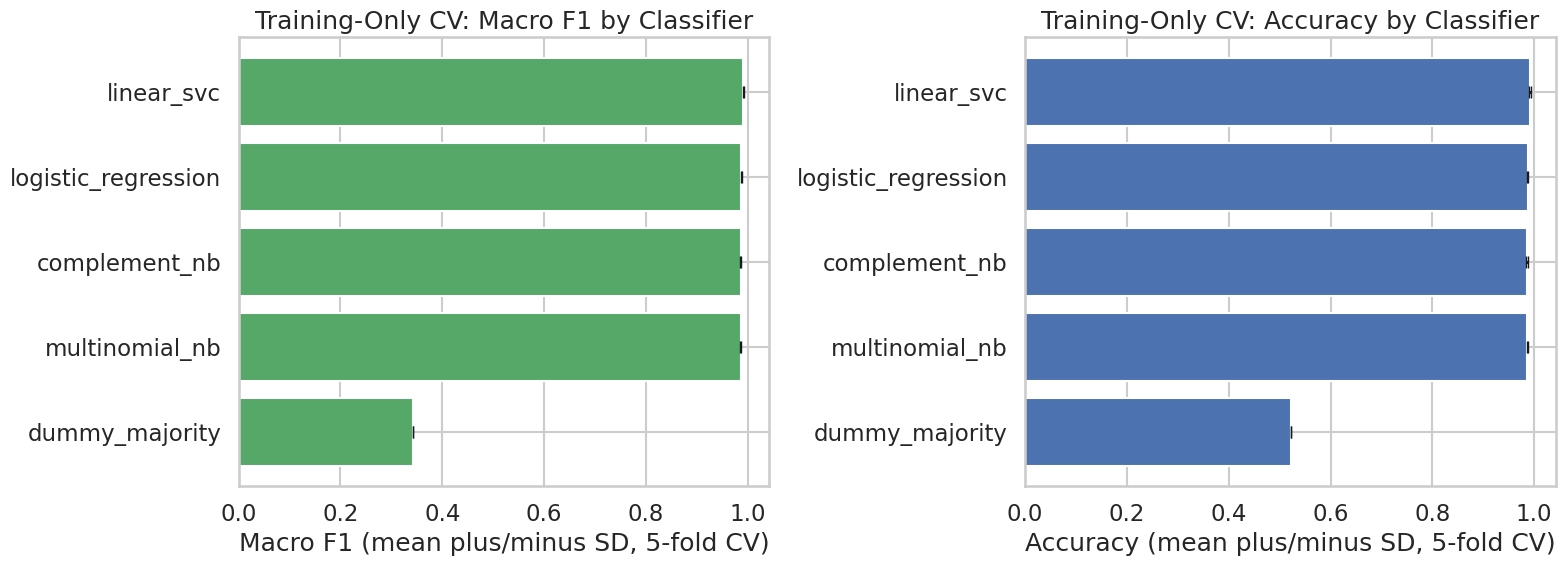

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_f1 = cv_results.sort_values("cv_macro_f1")
axes[0].barh(order_f1["model"], order_f1["cv_macro_f1"], xerr=order_f1["cv_macro_f1_sd"], color="#55A868", capsize=4)
axes[0].set_xlabel("Macro F1 (mean plus/minus SD, 5-fold CV)")
axes[0].set_title("Training-Only CV: Macro F1 by Classifier")

order_acc = cv_results.sort_values("cv_accuracy")
axes[1].barh(order_acc["model"], order_acc["cv_accuracy"], xerr=order_acc["cv_accuracy_sd"], color="#4C72B0", capsize=4)
axes[1].set_xlabel("Accuracy (mean plus/minus SD, 5-fold CV)")
axes[1].set_title("Training-Only CV: Accuracy by Classifier")

plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "cv_accuracy_and_macro_f1.png", dpi=150)
plt.show()

## 7. Locked-test evaluation

Every model is refit on the full training set and evaluated once on the held-out test set.

In [13]:
fitted_models = {}
predictions = {}
probabilities = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test)
    predictions[name] = pred

    classifier = model.named_steps["classifier"]
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, list(model.classes_).index("spam")]
    else:
        scores = model.decision_function(X_test)
        proba = (scores - scores.min()) / (scores.max() - scores.min())
    probabilities[name] = proba

print("All models fitted and evaluated on the locked test set.")

All models fitted and evaluated on the locked test set.


## 8. Regression-style error metrics (MAE / MSE / RMSE)

`label` is binary, so MAE, MSE, and RMSE are computed against each model's predicted spam probability (or normalized decision score for LinearSVC) rather than the hard prediction. This treats the score as a continuous estimate of the true label and reports how far, on average, that estimate is from the ground truth, complementing the classification metrics in Section 9.

In [14]:
y_test_numeric = (y_test == "spam").astype(int)

error_rows = []
for name in MODELS:
    proba = probabilities[name]
    mae = mean_absolute_error(y_test_numeric, proba)
    mse = mean_squared_error(y_test_numeric, proba)
    rmse = np.sqrt(mse)
    error_rows.append({"model": name, "MAE": mae, "MSE": mse, "RMSE": rmse})

error_df = pd.DataFrame(error_rows).sort_values("RMSE").reset_index(drop=True)
error_df.to_csv(OUT_DIR / "regression_style_errors.csv", index=False)
error_df.round(4)

,model,MAE,MSE,RMSE
0,complement_nb,0.0263,0.0101,0.1004
1,multinomial_nb,0.0267,0.0102,0.1011
2,logistic_regression,0.0712,0.0152,0.1234
3,linear_svc,0.2702,0.0816,0.2856
4,dummy_majority,0.4778,0.4778,0.6912


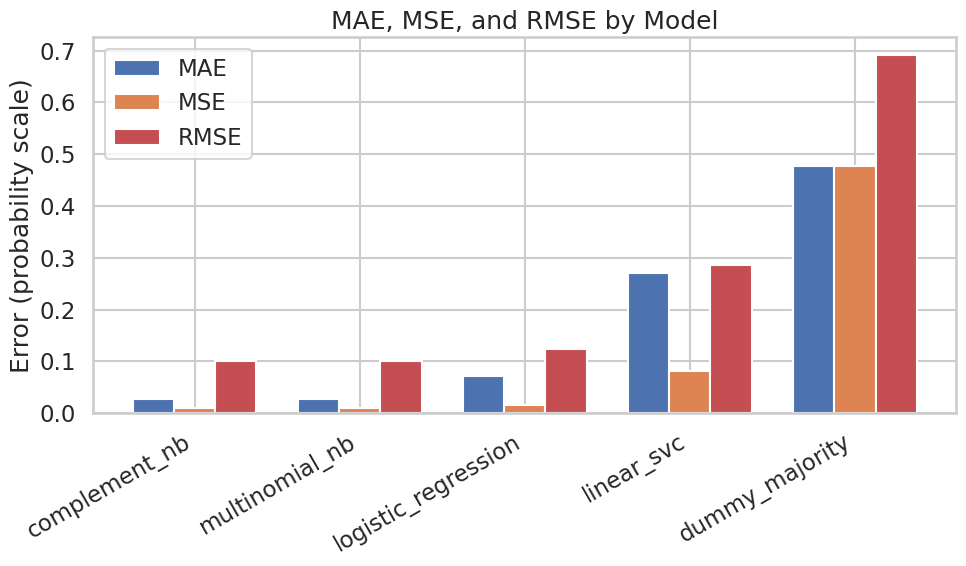

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(error_df))
width = 0.25
ax.bar(x - width, error_df["MAE"], width, label="MAE", color="#4C72B0")
ax.bar(x, error_df["MSE"], width, label="MSE", color="#DD8452")
ax.bar(x + width, error_df["RMSE"], width, label="RMSE", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(error_df["model"], rotation=30, ha="right")
ax.set_ylabel("Error (probability scale)")
ax.set_title("MAE, MSE, and RMSE by Model")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "regression_style_errors.png", dpi=150)
plt.show()

## 9. Classification metrics: accuracy, precision, recall, F1, ROC-AUC

In [16]:
metric_rows = []
for name in MODELS:
    pred = predictions[name]
    proba = probabilities[name]
    metric_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, pos_label="spam", zero_division=0),
        "recall": recall_score(y_test, pred, pos_label="spam", zero_division=0),
        "f1": f1_score(y_test, pred, pos_label="spam", zero_division=0),
        "roc_auc": roc_auc_score(y_test_numeric, proba),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values("f1", ascending=False).reset_index(drop=True)
metrics_df = metrics_df.merge(cv_results[["model", "cv_accuracy", "cv_macro_f1"]], on="model")
metrics_df.to_csv(OUT_DIR / "test_classification_metrics.csv", index=False)
metrics_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc,cv_accuracy,cv_macro_f1
0,linear_svc,0.9918,0.9874,0.9955,0.9914,0.9995,0.9918,0.9918
1,logistic_regression,0.9890,0.9811,0.9962,0.9886,0.9991,0.9876,0.9876
2,complement_nb,0.9880,0.9863,0.9887,0.9875,0.9989,0.9862,0.9862
3,multinomial_nb,0.9880,0.9870,0.9880,0.9875,0.9989,0.9862,0.9862
4,dummy_majority,0.5222,0.0000,0.0000,0.0000,0.5000,0.5223,0.3431


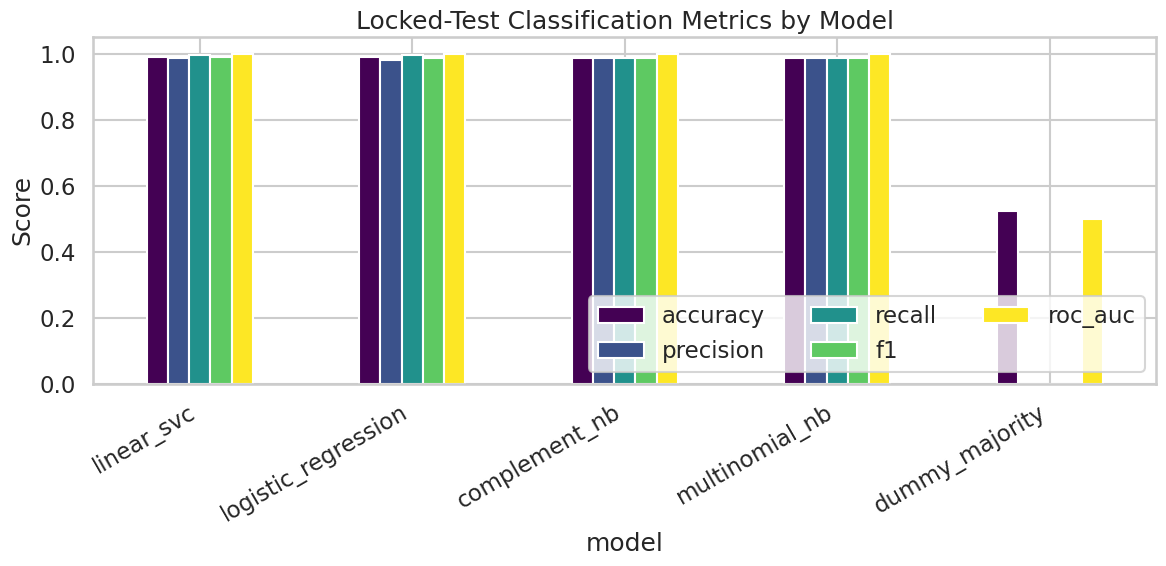

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_metrics = metrics_df.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]]
plot_metrics.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Locked-Test Classification Metrics by Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "classification_metrics_comparison.png", dpi=150)
plt.show()

In [18]:
best_model_name = metrics_df.iloc[0]["model"]
print(f"Best model by locked-test F1: {best_model_name}")
print()
print(classification_report(y_test, predictions[best_model_name], digits=4))

Best model by locked-test F1: linear_svc

              precision    recall  f1-score   support

         ham     0.9959    0.9884    0.9921      3182
        spam     0.9874    0.9955    0.9914      2911

    accuracy                         0.9918      6093
   macro avg     0.9916    0.9920    0.9918      6093
weighted avg     0.9918    0.9918    0.9918      6093



## 10. Visual diagnostics: confusion matrices, ROC curves, top predictive terms

### 10.1 Confusion matrices (all models)

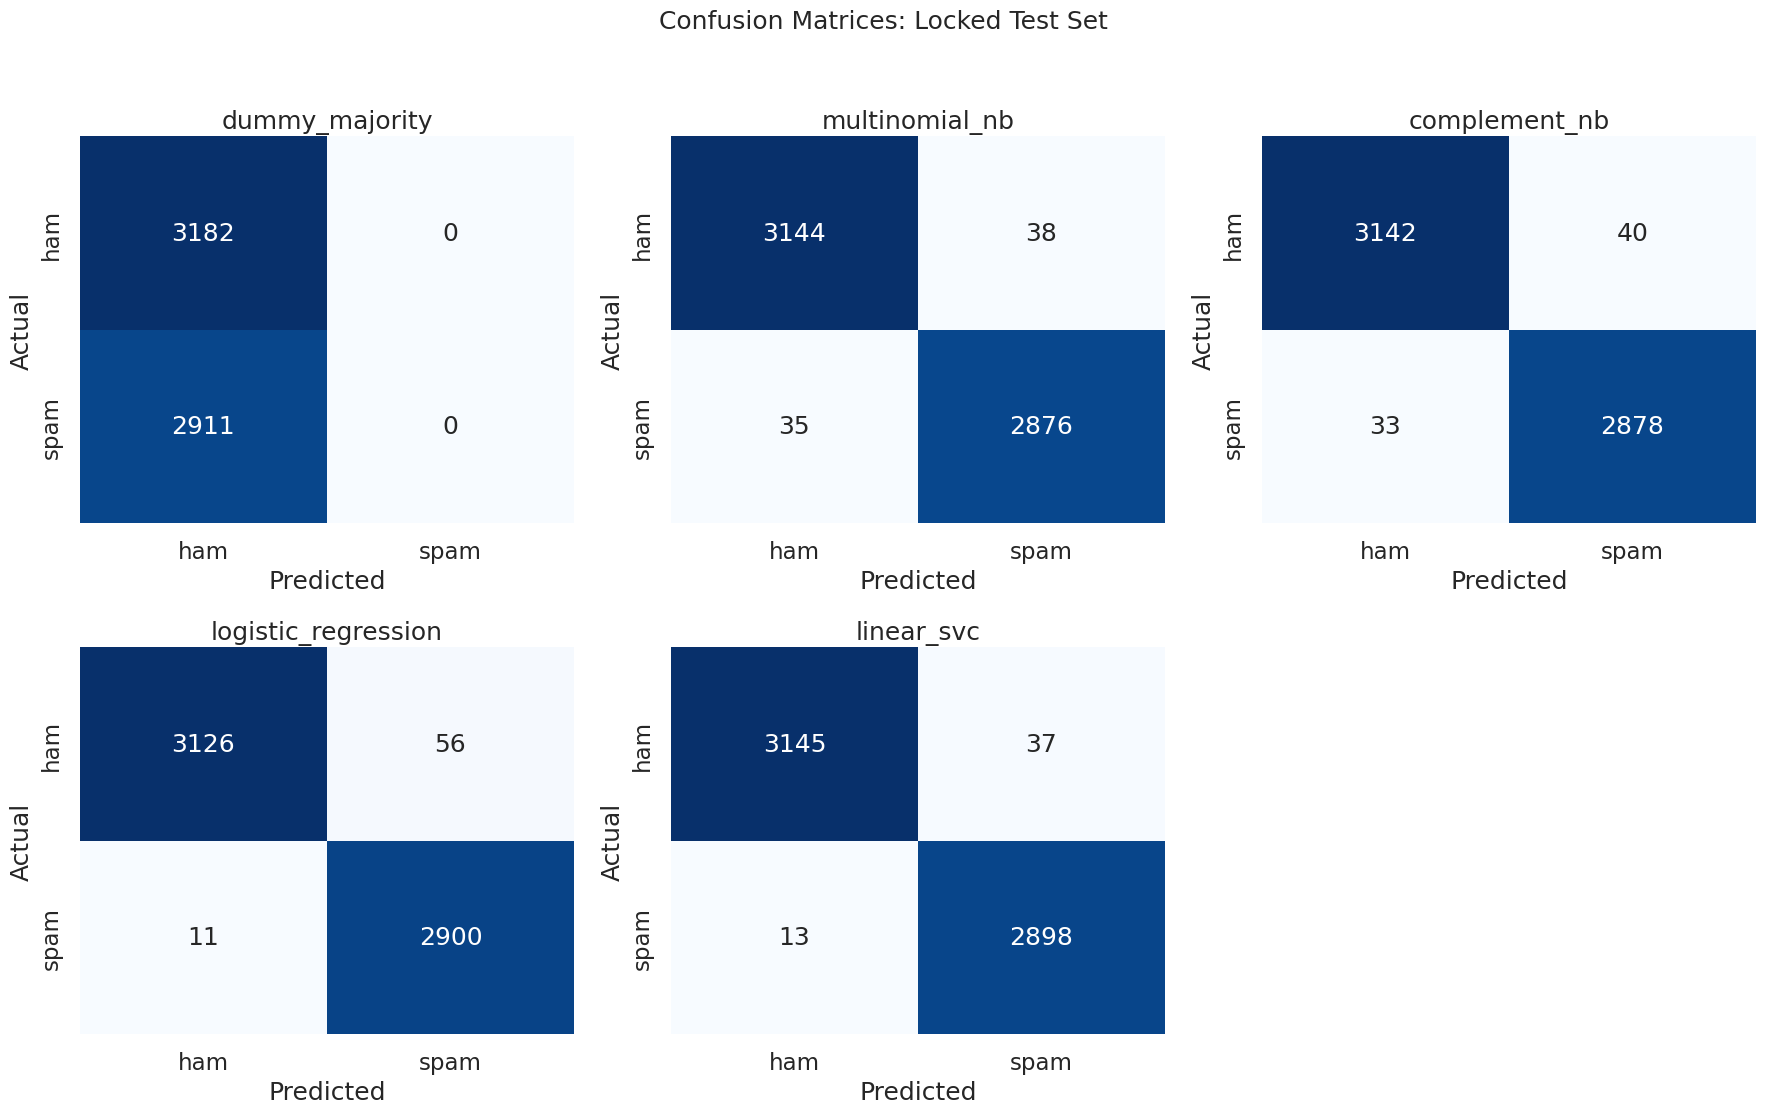

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
label_order = ["ham", "spam"]
for ax, name in zip(axes.ravel(), MODELS):
    cm = confusion_matrix(y_test, predictions[name], labels=label_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=label_order, yticklabels=label_order)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
axes.ravel()[-1].axis("off")
plt.suptitle("Confusion Matrices: Locked Test Set", y=1.02, fontsize=18)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.2 ROC curves (all models)

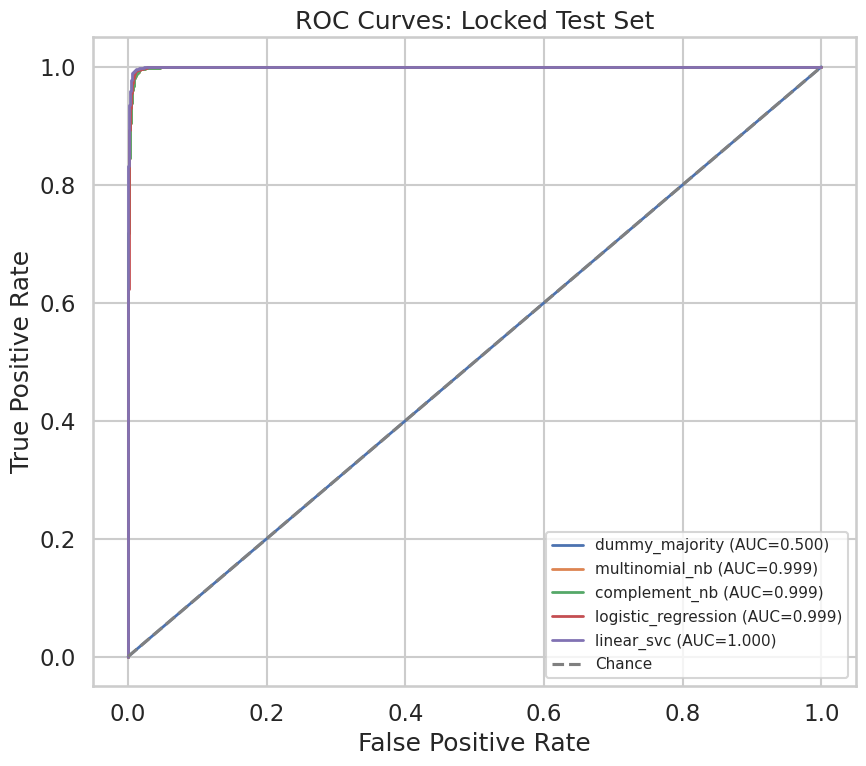

In [20]:
fig, ax = plt.subplots(figsize=(9, 8))
for name in MODELS:
    fpr, tpr, _ = roc_curve(y_test_numeric, probabilities[name])
    auc = roc_auc_score(y_test_numeric, probabilities[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Locked Test Set")
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "roc_curves.png", dpi=150)
plt.show()

### 10.3 Top predictive terms (Logistic Regression coefficients)

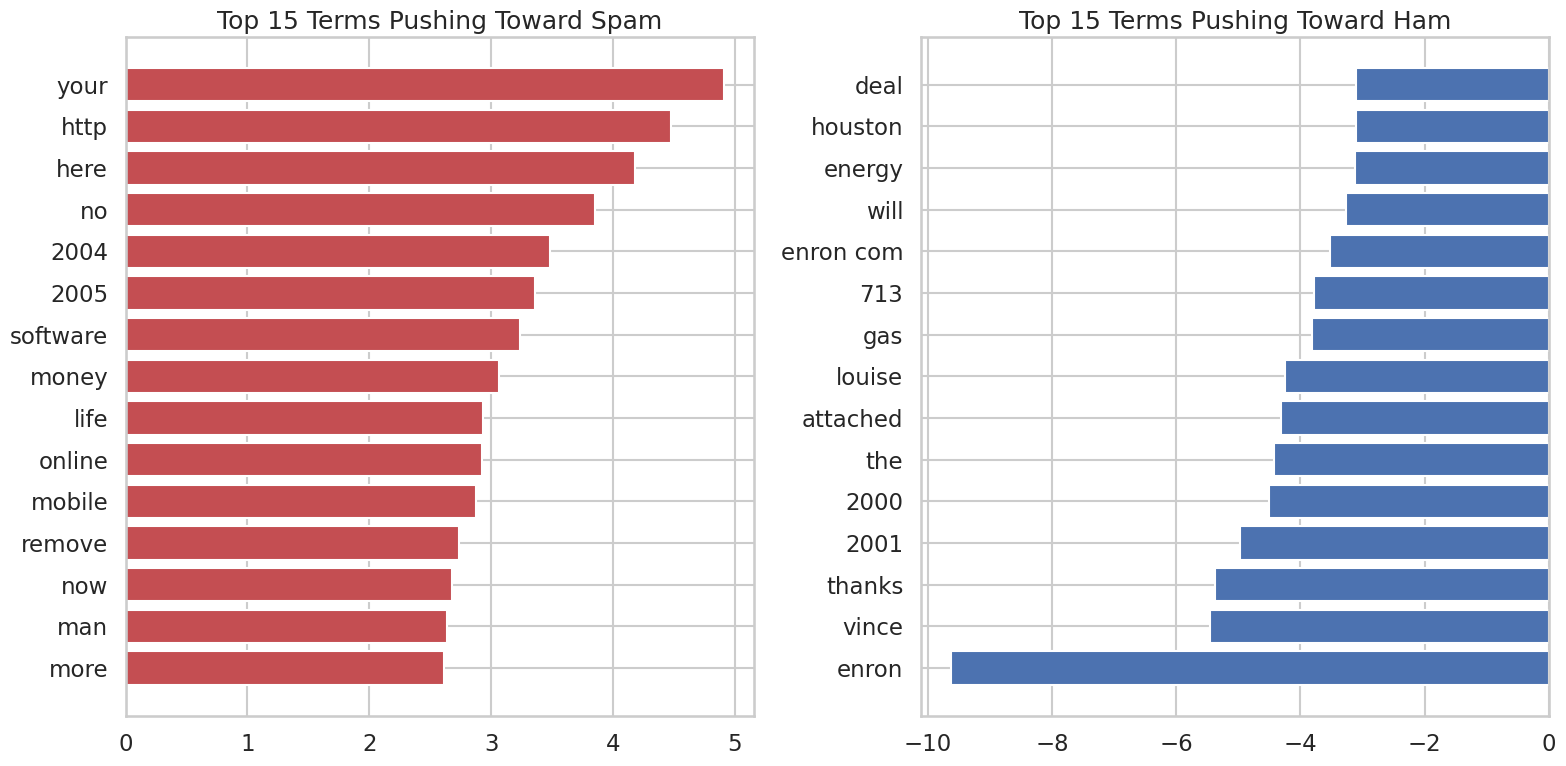

In [21]:
lr_pipeline = fitted_models["logistic_regression"]
vectorizer = lr_pipeline.named_steps["tfidf"]
classifier = lr_pipeline.named_steps["classifier"]

feature_names = np.array(vectorizer.get_feature_names_out())
spam_class_index = list(classifier.classes_).index("spam")
coefs = classifier.coef_[0] if len(classifier.classes_) == 2 else classifier.coef_[spam_class_index]

top_spam_idx = np.argsort(coefs)[-15:]
top_ham_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(feature_names[top_spam_idx], coefs[top_spam_idx], color="#C44E52")
axes[0].set_title("Top 15 Terms Pushing Toward Spam")
axes[1].barh(feature_names[top_ham_idx], coefs[top_ham_idx], color="#4C72B0")
axes[1].set_title("Top 15 Terms Pushing Toward Ham")
plt.tight_layout()
plt.savefig(OUT_DIR / "figures" / "top_predictive_terms.png", dpi=150)
plt.show()

## 11. Result tables and saved artifacts

In [22]:
summary = metrics_df.merge(error_df, on="model")
summary = summary.sort_values("f1", ascending=False).reset_index(drop=True)
summary.to_csv(OUT_DIR / "full_model_comparison_summary.csv", index=False)
summary.round(4)

,model,accuracy,precision,recall,f1,roc_auc,cv_accuracy,cv_macro_f1,MAE,MSE,RMSE
0,linear_svc,0.9918,0.9874,0.9955,0.9914,0.9995,0.9918,0.9918,0.2702,0.0816,0.2856
1,logistic_regression,0.9890,0.9811,0.9962,0.9886,0.9991,0.9876,0.9876,0.0712,0.0152,0.1234
2,complement_nb,0.9880,0.9863,0.9887,0.9875,0.9989,0.9862,0.9862,0.0263,0.0101,0.1004
3,multinomial_nb,0.9880,0.9870,0.9880,0.9875,0.9989,0.9862,0.9862,0.0267,0.0102,0.1011
4,dummy_majority,0.5222,0.0000,0.0000,0.0000,0.5000,0.5223,0.3431,0.4778,0.4778,0.6912


In [23]:
import joblib
best_name = summary.iloc[0]["model"]
joblib.dump(fitted_models[best_name], OUT_DIR / f"best_model_{best_name}.joblib")
print(f"Saved best model ({best_name}) to '{OUT_DIR}/'.")
print()
print("Saved files:")
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file():
        print(" -", f)

Saved best model (linear_svc) to 'outputs/'.

Saved files:
 - outputs/best_model_linear_svc.joblib
 - outputs/cv_results.csv
 - outputs/figures/class_distribution.png
 - outputs/figures/classification_metrics_comparison.png
 - outputs/figures/confusion_matrices.png
 - outputs/figures/correlation_heatmap_engineered.png
 - outputs/figures/cv_accuracy_and_macro_f1.png
 - outputs/figures/regression_style_errors.png
 - outputs/figures/roc_curves.png
 - outputs/figures/text_length_distributions.png
 - outputs/figures/top_predictive_terms.png
 - outputs/full_model_comparison_summary.csv
 - outputs/regression_style_errors.csv
 - outputs/test_classification_metrics.csv


## 12. Conclusion

- Dataset: Enron-Spam (33,716 emails, subject and body text), sourced as a raw-text alternative to Spambase so the required TF-IDF pipelines could be built.
- Five classifiers were compared with training-only cross-validation, then evaluated once on a locked test set: dummy baseline, MultinomialNB, ComplementNB, Logistic Regression, and LinearSVC.
- CV accuracy and CV macro F1 are both reported, alongside locked-test accuracy, precision, recall, F1, and ROC-AUC.
- MAE, MSE, and RMSE were computed against predicted spam probability (or normalized decision score) rather than the hard label, since the target is binary.
- A correlation heatmap of engineered numeric text features (length, word count, punctuation, capitalization) supplements the classification results, since raw TF-IDF features are too high-dimensional to correlate meaningfully.
- Logistic Regression coefficients highlight the terms most associated with spam and ham, giving an interpretable view of what the models learned.

### Relationship to the Lab 03 manual and pasted objectives

This notebook satisfies the objectives that a single-dataset classical benchmark can cover: leakage-safe TF-IDF pipelines, the five required classifiers, training-only repeated cross-validation with macro F1, and a locked-test evaluation with a full metric and visualization suite.

It does not yet cover: multi-dataset comparison and cross-dataset spam transfer, selective prediction tied to business-intent labels, the LLM API drafting stage, and the BiLSTM research extension. These require the business-intent dataset (D1) and, for the BiLSTM, a separate notebook given its training time and TensorFlow dependency.